In [1]:
from src.backtesting import VectorBTBacktester
import pandas as pd

d2 = pd.read_parquet('data/ml/d2_rehydrated.parquet')
trade_data = d2[d2['trade_id'] == 1]

backtester = VectorBTBacktester(trade_data)
portfolio = backtester.run_simulation(position_size=10000, fees=0.001)
metrics = backtester.get_metrics()

# Optional: visualize
backtester.plot_equity_curve()
backtester.plot_drawdown()


Loading data/ml/d2_rehydrated.parquet...
Loaded 431,540 rows, 14,448 unique trades
Analyzing 14,448 trades...


Processing trades: 100%|██████████| 14448/14448 [01:45<00:00, 137.34it/s]



Analysis complete: 14,448 trades processed

BACKTESTING REPORT

--- Overall Statistics ---
Total trades analyzed: 14,448
Average return: 4.54%
Median return: -0.24%
Win rate: 48.6%
Average Sharpe: 10.51
Average Sortino: inf
Average Max DD: -9.49%
Average Max Fav Exc: 12.34%
Average days held: 29.9
Average days to peak: 27.6

--- Winners (label=1) vs Losers (label=0) ---

Winners (1,488 trades):
  Avg return: 44.65%
  Avg Max DD: -13.66%
  Avg Max Fav Exc: 62.02%
  Avg Sharpe: 3.36
  Avg days to peak: 96.0

Losers (12,960 trades):
  Avg return: -0.07%
  Avg Max DD: -9.01%
  Avg Max Fav Exc: 6.63%
  Avg Sharpe: 11.34
  Avg days to peak: 19.8

--- Exit Reason Breakdown ---
            total_return_pct               max_dd_pct sharpe
                        mean median  count       mean   mean
exit_reason                                                 
trend_break             4.54  -0.24  14448      -9.49  10.51

--- Top 10 'Regret' Trades (High MFE but exited poorly) ---
       trade_id

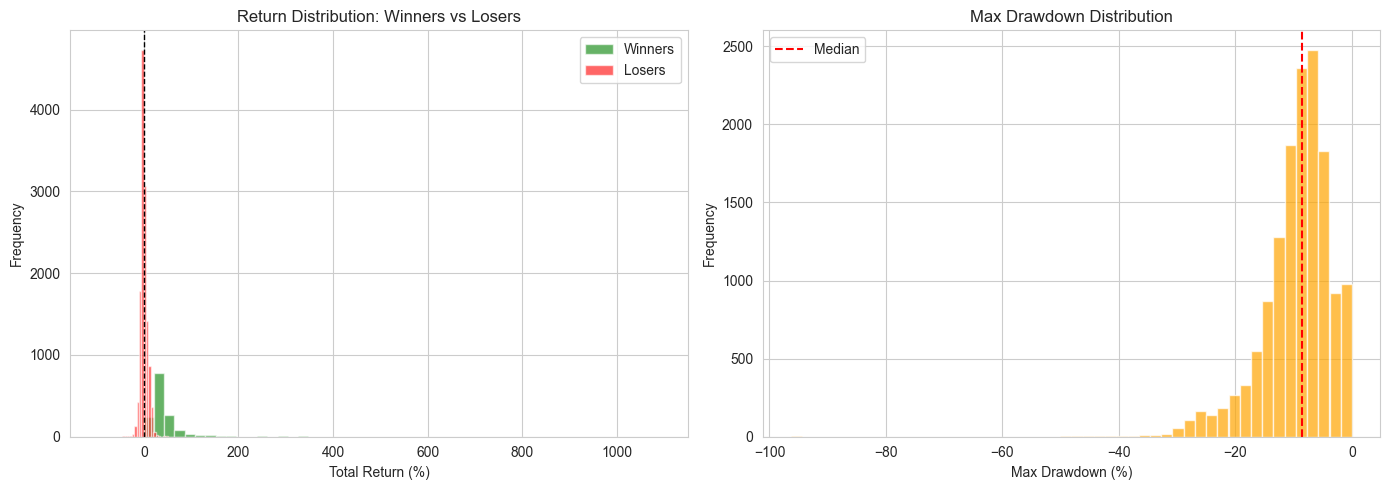

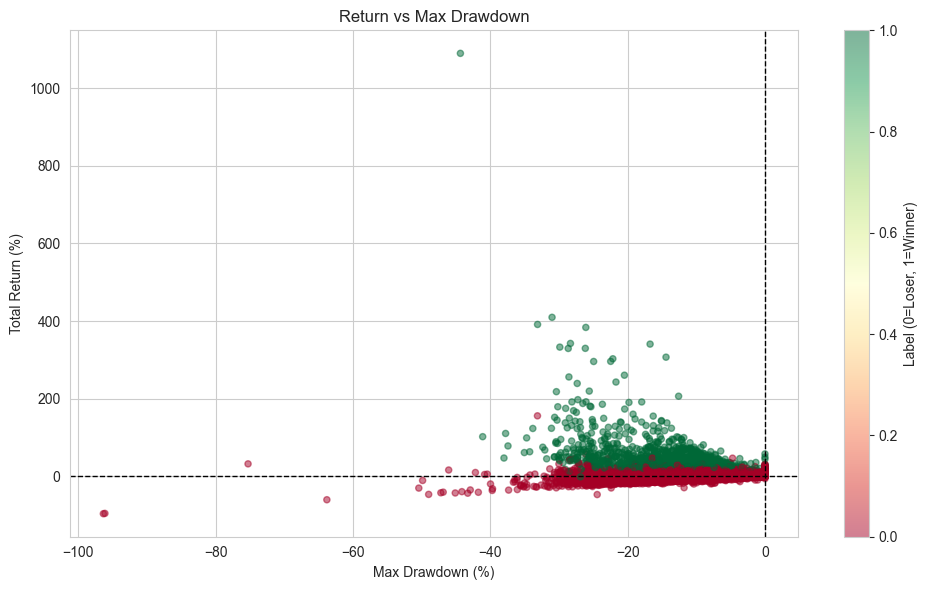

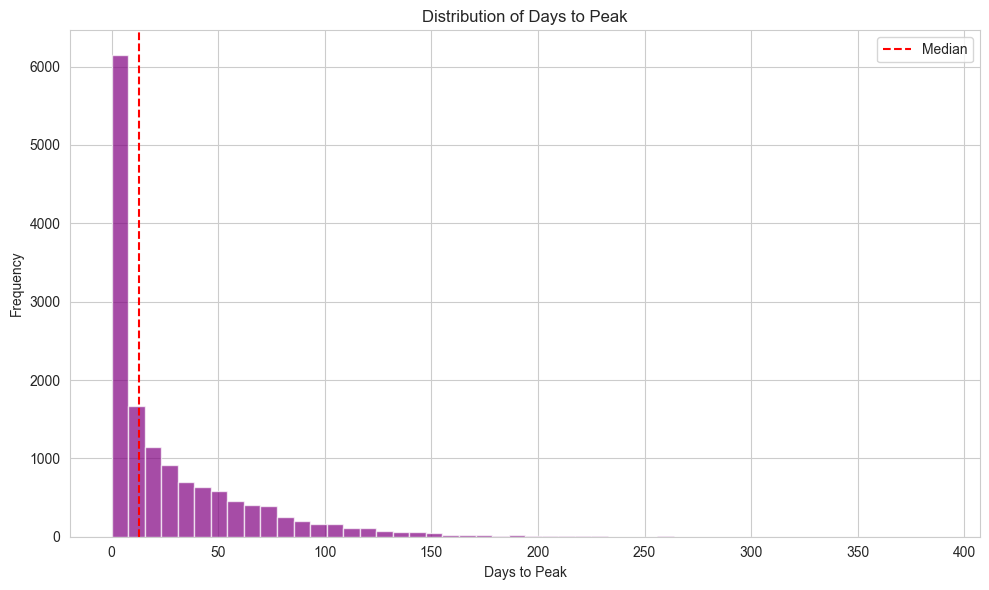

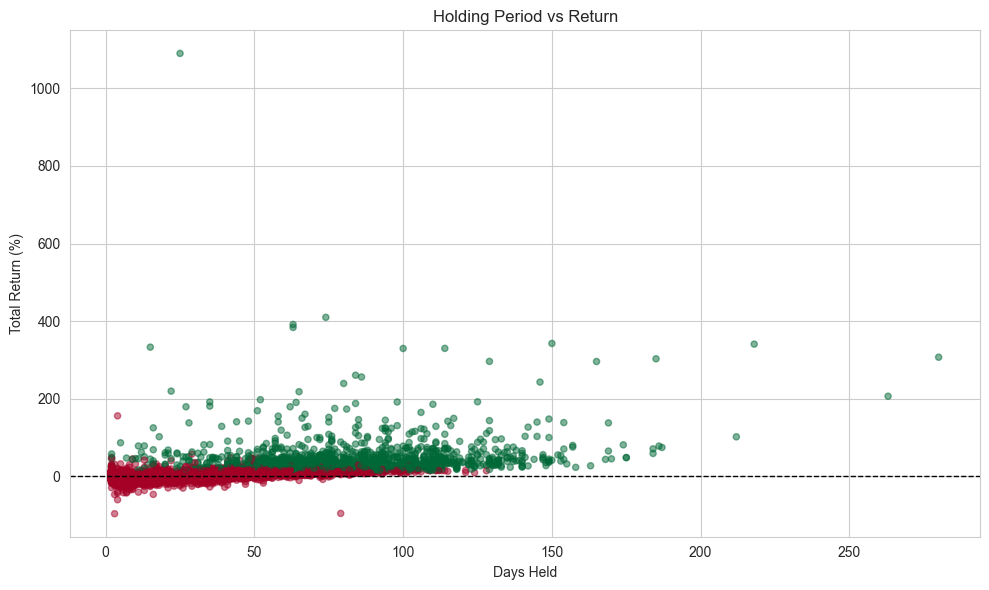

In [2]:
from src.backtesting import TradeAnalyzer

analyzer = TradeAnalyzer(d2_path='data/ml/d2_rehydrated.parquet')

# Analyze all trades (or use sample_size=N for subset)
results = analyzer.run_batch_analysis()

# Generate comprehensive report
analyzer.generate_report(save_plots=True, plot_dir='./backtest_results')

# Drill down into specific trade
portfolio = analyzer.get_portfolio(trade_id=123)
